# Nearest Neighbor Upsampling

**Nearest Neighbor Upsampling** is a straightforward image resizing technique that enlarges an image by replicating the values of the nearest pixel from the original image. It is computationally efficient but may produce blocky or pixelated artifacts.

## Mathematical Explanation

1. **Original Image and Resizing:**
   - Let $( I )$ be the original image with dimensions $( H \times W )$ (Height $(\times)$ Width).
   - We aim to resize $( I )$ to a new image with dimensions $( H' \times W' )$, where $( H' )$ and $( W' )$ are the new number of pixels.

2. **Scaling Factors:**
   - Define scaling factors $( \alpha )$ and $( \beta )$ for the height and width dimensions:
     $$
     \alpha = \frac{H'}{H}
     $$
     $$
     \beta = \frac{W'}{W}
     $$
   - These factors represent how many times larger the resized image will be compared to the original image.

3. **Pixel Mapping:**
   - For each pixel in the resized image at coordinates $( (x', y') )$, find the corresponding pixel in the original image:
     $$
     x = \left\lfloor \frac{x'}{\alpha} \right\rfloor
     $$
     $$
     y = \left\lfloor \frac{y'}{\beta} \right\rfloor
     $$
   - Here, $( \lfloor \cdot \rfloor )$ denotes the floor function, which rounds down to the nearest integer.

4. **Pixel Value Assignment:**
   - Assign the value of the pixel at $( (x', y') )$ in the resized image to the value of the pixel at $( (x, y) )$ in the original image:
     $$
     I'(x', y') = I(x, y)
     $$

## Practical Considerations

1. **Simplicity and Speed:**
   - Nearest Neighbor Upsampling is simple to implement and fast to execute, making it suitable for applications where computational efficiency is important.

2. **Image Artifacts:**
   - This method can produce blocky artifacts, especially noticeable in images with smooth transitions or gradients, due to the lack of interpolation between neighboring pixels.

3. **Applications:**
   - Often used in real-time image processing systems where speed is crucial, and in cases where image quality is less critical.

## Example Code

Here is a Python code snippet that demonstrates Nearest Neighbor Upsampling using the `PIL` library:


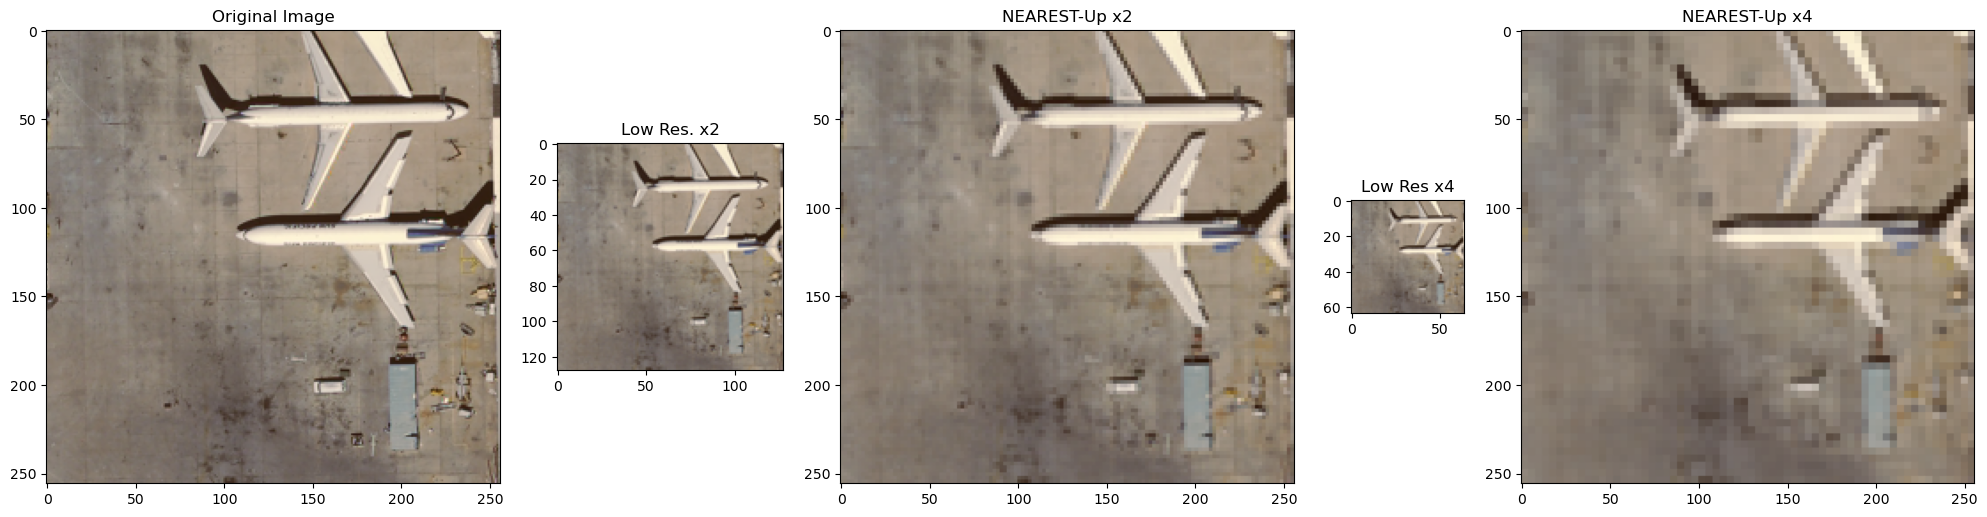

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

def nearest_neighbor_upsample(image, scale_factor):
    # Resize the image using nearest neighbor interpolation
    return image.resize(
        (int(image.width * scale_factor), int(image.height * scale_factor)), 
        Image.NEAREST
    )

# Load an image
image_hr = Image.open('./images/image_hr.png').convert('RGB')
image_lr_2 = Image.open('./images/image_lr_2.png').convert('RGB')
image_lr_4 = Image.open('./images/image_lr_4.png').convert('RGB')

# Perform upsampling with a scale factor of 2
scaled_image_2 = nearest_neighbor_upsample(image_lr_2, scale_factor=2)
scaled_image_4 = nearest_neighbor_upsample(image_lr_4, scale_factor=4)

# Create a figure with subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 0.5, 1, 0.25, 1]})

# Display each image in a subplot
axs[0].imshow(image_hr)
axs[0].set_title('Original Image')
axs[0].axis('on')

axs[1].imshow(image_lr_2)
axs[1].set_title('Low Res. x2')
axs[1].axis('on')

axs[2].imshow(scaled_image_2)
axs[2].set_title('NEAREST-Up x2')
axs[2].axis('on')

axs[3].imshow(image_lr_4)
axs[3].set_title('Low Res x4')
axs[3].axis('on')

axs[4].imshow(scaled_image_4)
axs[4].set_title('NEAREST-Up x4')
axs[4].axis('on')

# Adjust the layout to fit the images properly
plt.tight_layout()
plt.show()